# Phase 0 — Refaire les calculs du disparu

## Objectifs

- Télécharger la transmission Klaxo-3.
- Charger les relevés sans perdre silencieusement les lignes mal structurées.
- Choisir et justifier la date utilisée pour l'analyse.
- Reproduire les statistiques du dossier du 4 juillet.
- Produire la courbe annuelle des relevés.
- Afficher les dix journées les plus chargées.


## 1. Imports

In [1]:
from pathlib import Path
import csv
import urllib.request

import matplotlib.pyplot as plt
import pandas as pd


## 2. Configuration du projet

In [2]:
URL_DATA = (
    "https://raw.githubusercontent.com/planetsig/ufo-reports/master/"
    "csv-data/ufo-complete-geocoded-time-standardized.csv"
)

DATA_DIR = Path("../data")
OUTPUT_DIR = Path("../outputs")
PHASE0_DIR = OUTPUT_DIR / "phase_0_heritage"

DATA_DIR.mkdir(parents=True, exist_ok=True)
PHASE0_DIR.mkdir(parents=True, exist_ok=True)

DATA_PATH = DATA_DIR / "releves_klaxo3.csv"

COLUMNS = [
    "datetime",
    "city",
    "state",
    "country",
    "shape",
    "duration_seconds",
    "duration_hours_min",
    "comments",
    "date_posted",
    "latitude",
    "longitude",
]


## 3. Téléchargement des données

Le CSV est téléchargé automatiquement s'il n'est pas présent dans le dossier `data/`. Le fichier de données ne doit pas être ajouté au dépôt Git.

In [3]:
if not DATA_PATH.exists():
    print("Téléchargement du fichier...")
    urllib.request.urlretrieve(URL_DATA, DATA_PATH)
    print("Téléchargement terminé.")
else:
    print(f"Fichier déjà disponible : {DATA_PATH}")


Téléchargement du fichier...
Téléchargement terminé.


## 4. Chargement robuste des lignes

Les lignes ayant exactement 11 champs sont chargées dans le DataFrame principal. Les lignes présentant une autre structure sont conservées à part afin qu'aucune donnée ne disparaisse silencieusement.

In [4]:
lignes_valides = []
lignes_problemes = []

with open(
    DATA_PATH,
    "r",
    encoding="utf-8",
    errors="replace",
    newline="",
) as f:
    reader = csv.reader(f)

    for numero_ligne, row in enumerate(reader, start=1):
        if len(row) == len(COLUMNS):
            lignes_valides.append(row)
        else:
            lignes_problemes.append(
                {
                    "numero_ligne": numero_ligne,
                    "nombre_champs": len(row),
                    "contenu": row,
                }
            )

df = pd.DataFrame(lignes_valides, columns=COLUMNS)
df_lignes_problemes = pd.DataFrame(lignes_problemes)

print(f"Lignes chargées : {len(df)}")
print(f"Lignes isolées : {len(df_lignes_problemes)}")
print(f"Total vérifié : {len(df) + len(df_lignes_problemes)}")


Lignes chargées : 88679
Lignes isolées : 196
Total vérifié : 88875


## 5. Conversion des dates

Deux dates existent dans le fichier :

- `datetime` : date et heure de l'observation ;
- `date_posted` : date de publication ou de traitement.

Cette analyse utilise `datetime`, car elle répond à la question du dossier : à quel moment les témoins ont-ils observé un phénomène dans le ciel ?


In [5]:
df["datetime"] = pd.to_datetime(
    df["datetime"],
    errors="coerce",
)

df["date_posted"] = pd.to_datetime(
    df["date_posted"],
    errors="coerce",
)

df_dates = df.loc[
    df["datetime"].notna()
] .copy()

print(f"Relevés sans datetime : {df['datetime'].isna().sum()}")
print(f"Relevés utilisables pour l'analyse temporelle : {len(df_dates)}")


Relevés sans datetime : 1220
Relevés utilisables pour l'analyse temporelle : 87459


## 6. Période couverte et volume journalier moyen

In [6]:
date_min = df_dates["datetime"].dt.normalize().min()
date_max = df_dates["datetime"].dt.normalize().max()

nombre_jours = (date_max - date_min).days + 1
nombre_releves = len(df_dates)
moyenne_par_jour = nombre_releves / nombre_jours

print(f"Première date : {date_min.date()}")
print(f"Dernière date : {date_max.date()}")
print(f"Nombre de jours couverts : {nombre_jours}")
print(f"Nombre de relevés : {nombre_releves}")
print(f"Moyenne de relevés par jour : {moyenne_par_jour:.1f}")


Première date : 1906-11-11
Dernière date : 2014-05-08
Nombre de jours couverts : 39261
Nombre de relevés : 87459
Moyenne de relevés par jour : 2.2


## 7. Analyse du 4 juillet

Cette partie compte les signalements observés un 4 juillet, le maximum journalier sur toute la transmission et le rang du meilleur 4 juillet parmi toutes les journées.

In [7]:
df_dates["jour"] = df_dates["datetime"].dt.normalize()

releves_par_jour = (
    df_dates
    .groupby("jour")
    .size()
    .sort_values(ascending=False)
)

masque_4_juillet = (
    (df_dates["datetime"].dt.month == 7)
    & (df_dates["datetime"].dt.day == 4)
)

nombre_4_juillet = int(masque_4_juillet.sum())
maximum_journalier = int(releves_par_jour.max())

jours_4_juillet = releves_par_jour.loc[
    releves_par_jour.index.map(
        lambda date: date.month == 7 and date.day == 4
    )
]

rangs_journaliers = releves_par_jour.rank(
    method="min",
    ascending=False,
)

rang_4_juillet = int(
    rangs_journaliers.loc[jours_4_juillet.index].min()
)

print(f"Signalements observés un 4 juillet : {nombre_4_juillet}")
print(f"Maximum de signalements sur une journée : {maximum_journalier}")
print(f"Meilleur rang atteint par un 4 juillet : {rang_4_juillet}")


Signalements observés un 4 juillet : 1271
Maximum de signalements sur une journée : 206
Meilleur rang atteint par un 4 juillet : 1


## 8. Répartition par jour de semaine et par mois

In [8]:
ordre_jours = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday",
]

df_dates["jour_semaine"] = pd.Categorical(
    df_dates["datetime"].dt.day_name(),
    categories=ordre_jours,
    ordered=True,
)

repartition_jours = (
    df_dates["jour_semaine"]
    .value_counts(normalize=True)
    .reindex(ordre_jours)
    .mul(100)
)

repartition_mois = (
    df_dates["datetime"]
    .dt.month
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
)

print("Répartition par jour de semaine :")
display(repartition_jours.round(2))

print("Répartition par mois :")
display(repartition_mois.round(2))


Répartition par jour de semaine :


jour_semaine
Monday       12.59
Tuesday      13.44
Wednesday    13.65
Thursday     13.70
Friday       14.41
Saturday     17.44
Sunday       14.77
Name: proportion, dtype: float64

Répartition par mois :


datetime
1      7.17
2      5.84
3      6.80
4      6.87
5      6.62
6     10.19
7     11.71
8     10.67
9      9.41
10     9.22
11     8.42
12     7.08
Name: proportion, dtype: float64

## 9. Courbe annuelle du volume de relevés

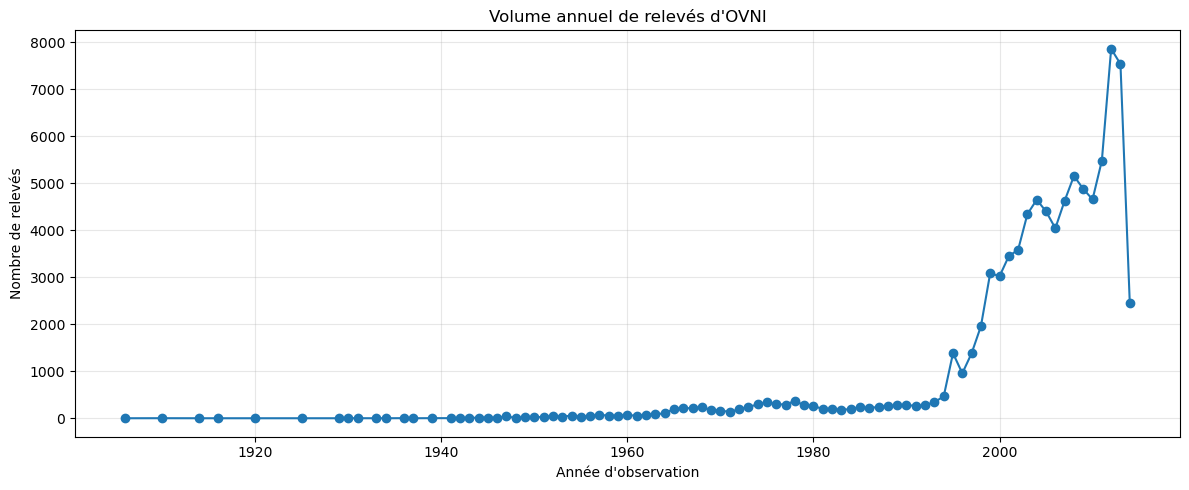

In [9]:
releves_annuels = (
    df_dates
    .groupby(df_dates["datetime"].dt.year)
    .size()
)

plt.figure(figsize=(12, 5))
plt.plot(
    releves_annuels.index,
    releves_annuels.values,
    marker="o",
)
plt.title("Volume annuel de relevés d'OVNI")
plt.xlabel("Année d'observation")
plt.ylabel("Nombre de relevés")
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(
    PHASE0_DIR / "courbe_volume_annuel.png",
    dpi=150,
)

plt.show()


## 10. Les dix journées les plus chargées

In [10]:
top_10_jours = (
    releves_par_jour
    .head(10)
    .rename("nombre_releves")
    .reset_index()
)

top_10_jours


,jour,nombre_releves
0,2010-07-04,206
1,1999-11-16,195
2,2012-07-04,191
3,2013-07-04,180
4,2011-07-04,155
5,2009-09-19,129
6,2014-01-01,99
7,2013-12-31,96
8,2004-10-31,94
9,2009-07-04,87


## 11. Export des résultats

In [11]:
df_lignes_problemes.to_csv(
    PHASE0_DIR / "lignes_problemes_chargement.csv",
    index=False,
)

top_10_jours.to_csv(
    PHASE0_DIR / "top_10_journees.csv",
    index=False,
)

releves_annuels.rename(
    "nombre_releves"
).reset_index(
    name="nombre_releves"
).to_csv(
    PHASE0_DIR / "volume_annuel.csv",
    index=False,
)

repartition_jours.rename(
    "pourcentage"
).reset_index(
    name="pourcentage"
).rename(
    columns={"jour_semaine": "jour"}
).to_csv(
    PHASE0_DIR / "repartition_jours.csv",
    index=False,
)

repartition_mois.rename(
    "pourcentage"
).reset_index(
    name="pourcentage"
).rename(
    columns={"datetime": "mois"}
).to_csv(
    PHASE0_DIR / "repartition_mois.csv",
    index=False,
)

resume_phase0 = pd.DataFrame(
    [
        {
            "date_utilisee": "datetime",
            "date_min": date_min,
            "date_max": date_max,
            "nombre_jours": nombre_jours,
            "nombre_releves": nombre_releves,
            "moyenne_releves_jour": moyenne_par_jour,
            "releves_4_juillet": nombre_4_juillet,
            "maximum_journalier": maximum_journalier,
            "rang_4_juillet": rang_4_juillet,
            "part_samedi_pct": repartition_jours["Saturday"],
            "part_lundi_pct": repartition_jours["Monday"],
            "part_juillet_pct": repartition_mois.loc[7],
            "part_fevrier_pct": repartition_mois.loc[2],
        }
    ]
)

resume_phase0.to_csv(
    PHASE0_DIR / "resume_phase0.csv",
    index=False,
)

print("Fichiers exportés dans :")
print(PHASE0_DIR)


Fichiers exportés dans :
..\outputs\phase_0_heritage
